In [1]:
import pandas as pd

df = pd.read_csv("../data/iris_dataset.csv")

df.head(10)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [2]:
print(df.shape)

(150, 5)


In [3]:
print(df.columns.tolist())

['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'species']


In [4]:
print(df.dtypes)

sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
species                str
dtype: object


Text(0, 0.5, 'Longitud (cm)')

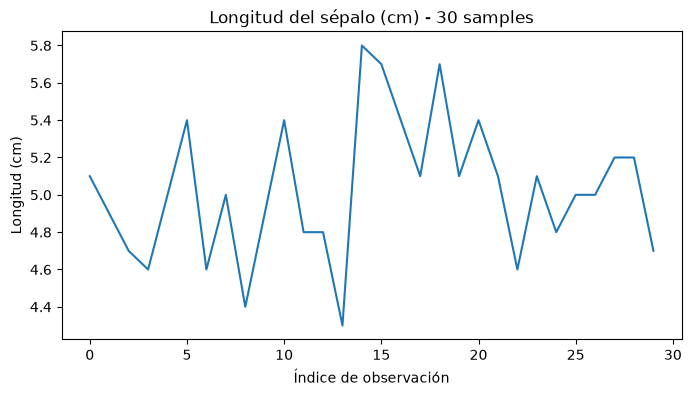

In [ ]:
# 2. Línea: secuencia de observaciones
# Grafica con una línea la variable `sepal_length_cm` de las primeras 30 observaciones. Usa el índice de la fila como eje X. Agrega título y etiquetas a ambos ejes. Explica en una frase qué representa el orden en este caso.

import matplotlib.pyplot as plt

subconjunto = df.loc[0:29, :]
# subconjunto

plt.figure(figsize=(8, 4))
plt.plot(subconjunto.index, subconjunto['sepal_length_cm'])
plt.title('Longitud del sépalo (cm) - 30 samples')
plt.xlabel('Índice de observación')
plt.ylabel('Longitud (cm)')

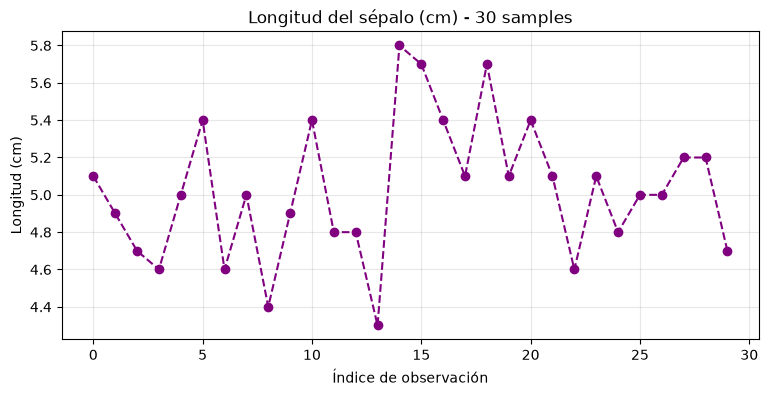

In [12]:
# 3. Línea: personalización
# Repite el gráfico anterior usando marcador circular, línea discontinua y un color diferente. Ajusta el tamaño de la figura y agrega una cuadrícula suave.

subconjunto = df.loc[0:29, :]

plt.figure(figsize=(9, 4))
plt.plot(subconjunto.index, 
         subconjunto['sepal_length_cm'], 
         marker='o', 
         linestyle='--',
         color='purple'
)
plt.title('Longitud del sépalo (cm) - 30 samples')
plt.xlabel('Índice de observación')
plt.ylabel('Longitud (cm)')
plt.grid(alpha=0.3)

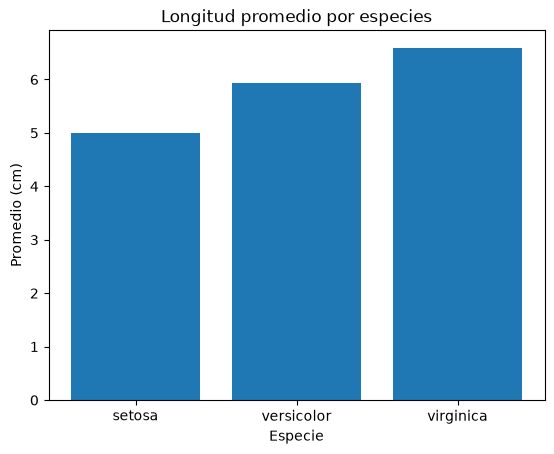

In [14]:
# 4. Barras: promedio por especie
# Calcula el promedio de `sepal_length_cm` para cada `species` y represéntalo con un gráfico de barras verticales. Incluye etiquetas de ejes y título.

promedio_sepal_length = df.groupby('species')['sepal_length_cm'].mean()

plt.bar(promedio_sepal_length.index, promedio_sepal_length.values)
plt.title('Longitud promedio por especies')
plt.xlabel('Especie')
plt.ylabel('Promedio (cm)')
plt.show()

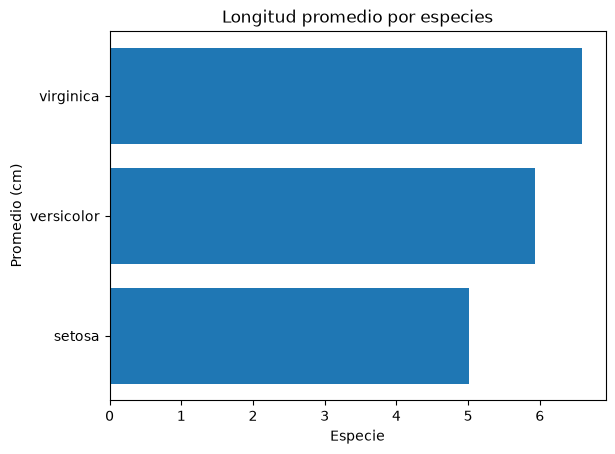

In [15]:
# 5. Barras horizontales
# Calcula el promedio de `petal_length_cm` por especie y crea un gráfico de barras horizontales. Ordena las especies de menor a mayor promedio antes de graficar.

promedio_sepal_length = df.groupby('species')['sepal_length_cm'].mean().sort_values()

plt.barh(promedio_sepal_length.index, promedio_sepal_length.values)
plt.title('Longitud promedio por especies')
plt.xlabel('Especie')
plt.ylabel('Promedio (cm)')
plt.show()

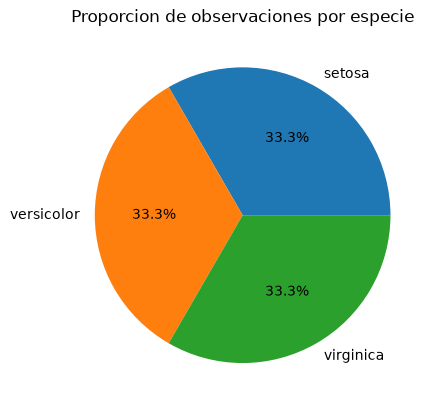

In [18]:
# 6. Pastel: composición del dataset
# Calcula cuántas observaciones existen por especie y represéntalas con un gráfico de pastel. Muestra los porcentajes con un decimal. ¿Qué conclusión obtienes sobre el balance del dataset?


counts = df['species'].value_counts()
counts

plt.Figure(figsize=(6, 6))
plt.pie(counts.values, labels= counts.index, autopct='%1.1f%%')
plt.title('Proporcion de observaciones por especie')
plt.show()


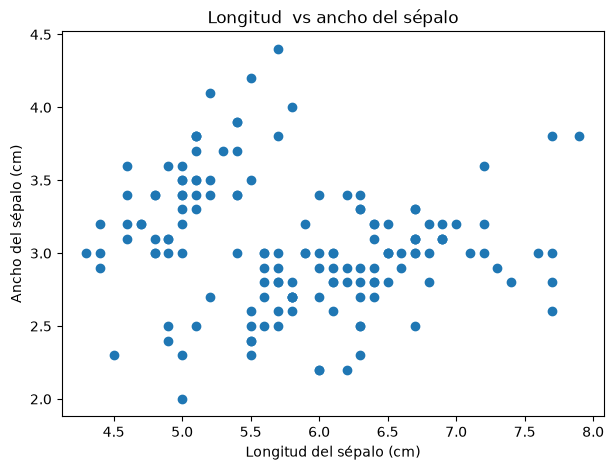

In [20]:
# 7. Dispersión: sépalo
# Crea un scatter plot entre `sepal_length_cm` y `sepal_width_cm`. Agrega título y etiquetas. Describe si visualmente parece existir una relación clara entre ambas variables.

plt.figure(figsize=(7, 5))
plt.scatter(df['sepal_length_cm'],df['sepal_width_cm'])
plt.title('Longitud  vs ancho del sépalo')
plt.xlabel('Longitud del sépalo (cm)')
plt.ylabel('Ancho del sépalo (cm)')
plt.show()

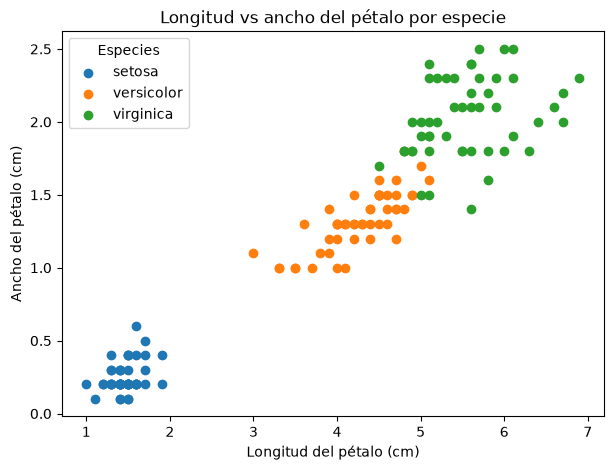

In [22]:
# 8. Dispersión por especie
# Crea un gráfico de dispersión entre `petal_length_cm` y `petal_width_cm`, diferenciando cada especie con una serie distinta y una leyenda. No uses Seaborn.


plt.figure(figsize=(7, 5))
for species, gruop in df.groupby('species'):
    plt.scatter(
        gruop['petal_length_cm'],
        gruop['petal_width_cm'],
        label=species,
    )

plt.title('Longitud vs ancho del pétalo por especie')
plt.xlabel('Longitud del pétalo (cm)')
plt.ylabel('Ancho del pétalo (cm)')
plt.legend(title='Especies')
plt.show()

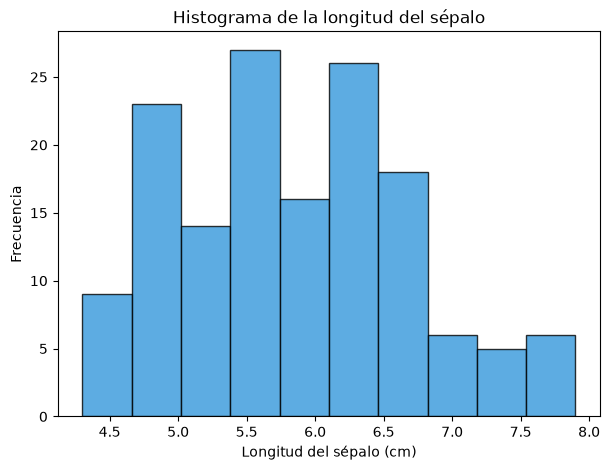

In [ ]:
# 9. Histograma: longitud del sépalo
#  Crea un histograma de sepal_length_cm con 10 bins, borde visible y etiquetas. Describe dónde se
# concentra la mayor parte de las observaciones.

plt.figure(figsize=(7, 5))
plt.hist(
    df["sepal_length_cm"],
    bins=10,
    edgecolor="black",
    color="#3498db",
    alpha=0.8,
)
plt.title("Histograma de la longitud del sépalo")
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("Frecuencia")
plt.show()

# Descripción: La mayor parte de las observaciones se concentra en el rango de 5.0 cm a 6.5 cm, registrando la frecuencia más alta (el pico principal) en el intervalo comprendido entre 5.5 y 6.0 cm.

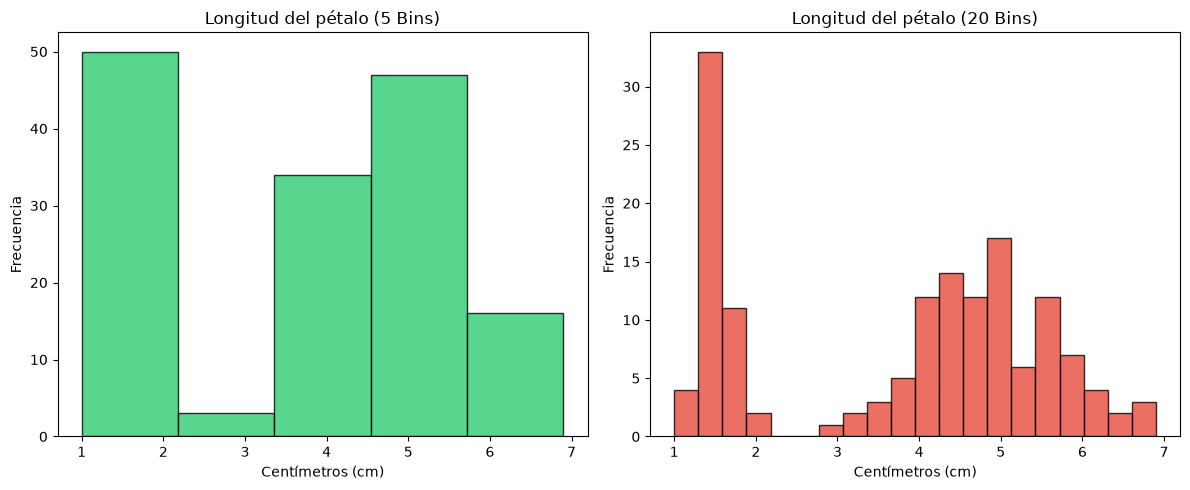

In [ ]:
# 10. Histograma y bins Crea dos histogramas de petal_length_cm: uno con 5 bins y otro con 20 bins. Colócalos lado a lado
#  usando subplots. Explica brevemente cómo cambia la interpretación al modificar los bins.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histograma con 5 bins
ax1.hist(
    df["petal_length_cm"],
    bins=5,
    edgecolor="black",
    color="#2ecc71",
    alpha=0.8,
)
ax1.set_title("Longitud del pétalo (5 Bins)")
ax1.set_xlabel("Centímetros (cm)")
ax1.set_ylabel("Frecuencia")

# Histograma con 20 bins
ax2.hist(
    df["petal_length_cm"],
    bins=20,
    edgecolor="black",
    color="#e74c3c",
    alpha=0.8,
)
ax2.set_title("Longitud del pétalo (20 Bins)")
ax2.set_xlabel("Centímetros (cm)")
ax2.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Explicación: Con 5 bins, la visión es muy general y se pierde el detalle de la distribución, ocultando por ejemplo la clara separación bimodal o trimodal de los datos. 
# Con 20 bins, se aprecia con mayor precisión la distribución real de los datos y se revelan con nitidez los espacios o baches vacíos entre las diferentes especies.

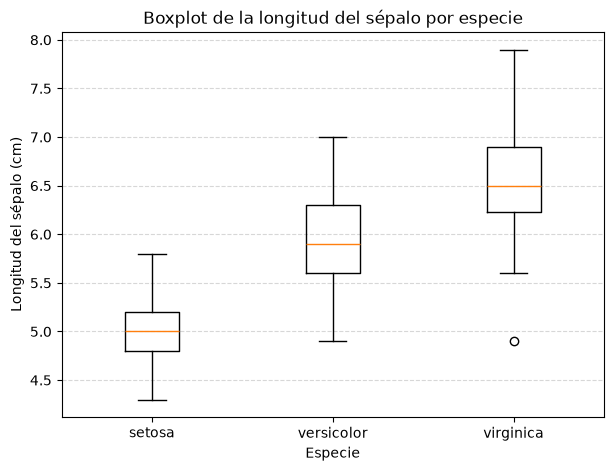

In [27]:
# 11. Boxplot por especie
#  Construye un boxplot de sepal_length_cm separado por especie. Etiqueta cada caja con el nombre de
# su especie y compara visualmente las medianas.

especies = df["species"].unique()
datos_por_especie = [
    df[df["species"] == esp]["sepal_length_cm"] for esp in especies
]

plt.figure(figsize=(7, 5))

# 1. Creamos el boxplot sin el argumento 'labels'
plt.boxplot(datos_por_especie)

# 2. Asignamos las etiquetas de las especies en el eje X de forma manual
plt.xticks(range(1, len(especies) + 1), especies)

plt.title("Boxplot de la longitud del sépalo por especie")
plt.xlabel("Especie")
plt.ylabel("Longitud del sépalo (cm)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

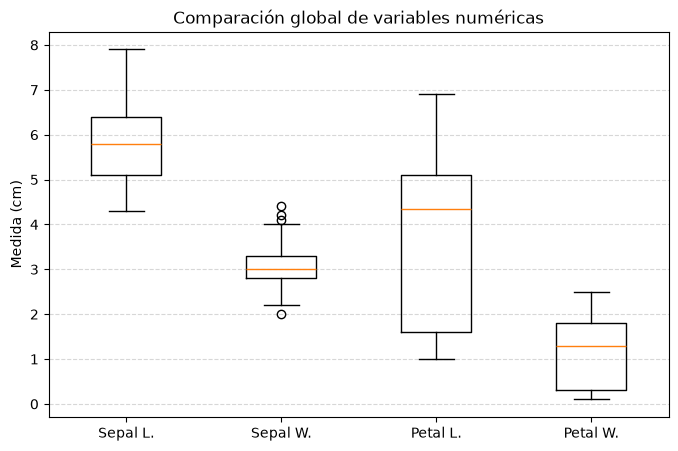

In [ ]:
# 12. Boxplot de variables numéricas
#  Crea un solo boxplot que compare las cuatro variables numéricas del dataset. Usa etiquetas cortas y
#  legibles para cada caja. ¿Qué problema de escala observas?

columnas_numericas = [
    "sepal_length_cm",
    "sepal_width_cm",
    "petal_length_cm",
    "petal_width_cm",
]
datos_numericos = [df[col] for col in columnas_numericas]
etiquetas_cortas = ["Sepal L.", "Sepal W.", "Petal L.", "Petal W."]

plt.figure(figsize=(8, 5))

# 1. Se dibuja el boxplot sin el argumento 'labels'
plt.boxplot(datos_numericos)

# 2. Se asignan las etiquetas en el eje X de forma manual
plt.xticks(range(1, len(etiquetas_cortas) + 1), etiquetas_cortas)

plt.title("Comparación global de variables numéricas")
plt.ylabel("Medida (cm)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# Problema de escala: Las variables de longitud (sepal_length_cm y petal_length_cm) alcanzan valores superiores a 7 u 8 cm, mientras que las variables de ancho 
# (especialmente petal_width_cm) se mueven en rangos muy pequeños (desde 0.1 hasta 2.5 cm). Al graficarlas juntas en el mismo eje, las cajas con valores pequeños quedan 
# comprimidas y aplastadas en la parte inferior, dificultando la visualización correcta de su dispersión y cuartiles.

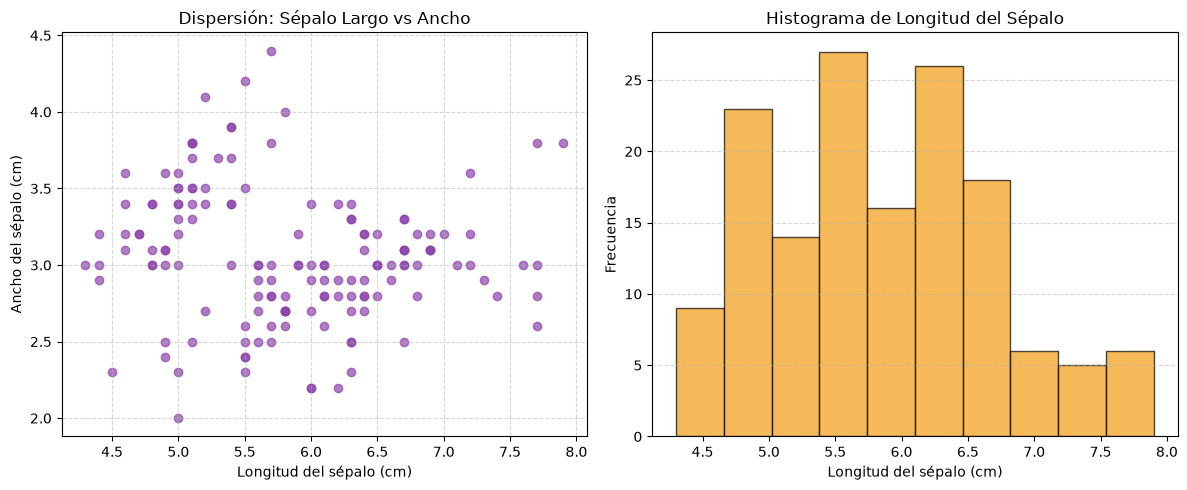

In [30]:
# 13. Subplots 1x2
#  Crea una figura con dos subplots: a la izquierda un scatter de sepal_length_cm vs. sepal_width_cm; a
#  la derecha un histograma de sepal_length_cm. Agrega un título independiente a cada panel.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Panel izquierdo: Scatter plot
ax1.scatter(
    df["sepal_length_cm"],
    df["sepal_width_cm"],
    color="#8e44ad",
    alpha=0.7,
)
ax1.set_title("Dispersión: Sépalo Largo vs Ancho")
ax1.set_xlabel("Longitud del sépalo (cm)")
ax1.set_ylabel("Ancho del sépalo (cm)")
ax1.grid(True, linestyle="--", alpha=0.5)

# Panel derecho: Histograma
ax2.hist(
    df["sepal_length_cm"],
    bins=10,
    edgecolor="black",
    color="#f39c12",
    alpha=0.7,
)
ax2.set_title("Histograma de Longitud del Sépalo")
ax2.set_xlabel("Longitud del sépalo (cm)")
ax2.set_ylabel("Frecuencia")
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

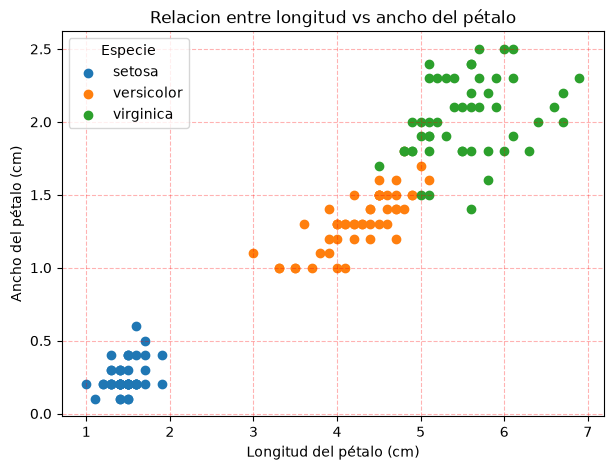

In [31]:
# 15. Leyendas y etiquetas
# Crea nuevamente el scatter de `petal_length_cm` vs. `petal_width_cm` por especie. Esta vez agrega título general, etiquetas de ejes, leyenda y cuadrícula. La figura debe ser autoexplicativa sin leer el código.

fig, ax = plt.subplots(figsize=(7,5))
for species, gruop in df.groupby('species'):
    plt.scatter(
        gruop['petal_length_cm'],
        gruop['petal_width_cm'],
        label=species,
    )

ax.set_title('Relacion entre longitud vs ancho del pétalo')
ax.set_xlabel('Longitud del pétalo (cm)')
ax.set_ylabel('Ancho del pétalo (cm)')
ax.legend(title='Especie')
ax.grid(color='red', linestyle='--', alpha=0.3)
plt.show()


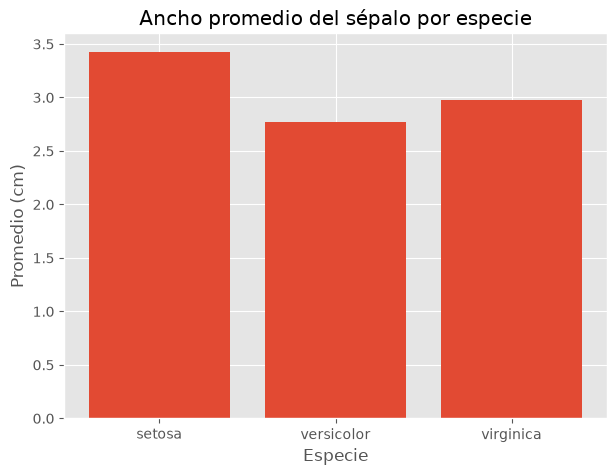

In [34]:
# 16. Estilos
# Aplica temporalmente el estilo `ggplot` a un gráfico de barras con el promedio de `sepal_width_cm` por especie. Al terminar, restaura el estilo `default` para no afectar gráficos posteriores.

mean_sepal_wiidth = df.groupby('species')['sepal_width_cm'].mean()

plt.style.use('ggplot')
fix, ax = plt.subplots(figsize=(7, 5))
ax.bar(mean_sepal_wiidth.index, mean_sepal_wiidth.values)
ax.set_title('Ancho promedio del sépalo por especie')
ax.set_xlabel('Especie')
ax.set_ylabel('Promedio (cm)')
plt.show()

# plt.style.use('default')

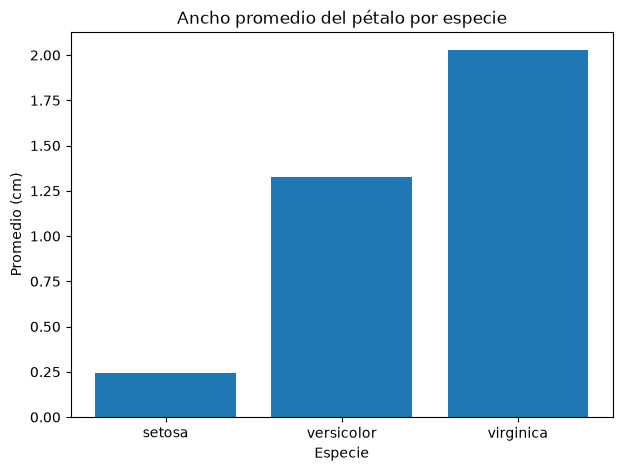

In [ ]:
# 17. POO: Figure y Axes
# Usando exclusivamente el enfoque orientado a objetos (`fig, ax = plt.subplots()`), crea un gráfico de barras con el promedio de `petal_width_cm` por especie. Configura título y etiquetas con métodos de `Axes`.

mean_petal_width = df.groupby('species')['petal_width_cm'].mean()

# plt.style.use('ggplot')
fix, ax = plt.subplots(figsize=(7, 5))
ax.bar(mean_petal_width.index, mean_petal_width.values)
ax.set_title('Ancho promedio del pétalo por especie')
ax.set_xlabel('Especie')
ax.set_ylabel('Promedio (cm)')
plt.show()


# plt.style.use('default')

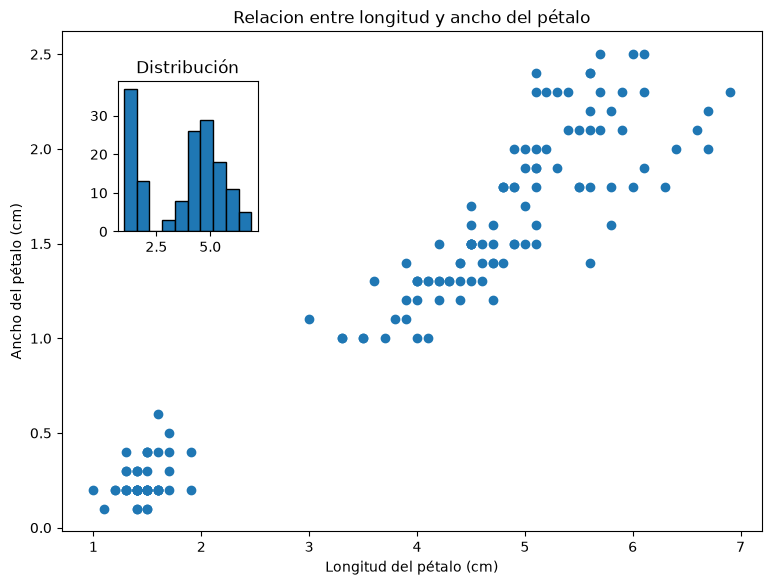

In [ ]:

# 19. Gráfico principal + gráfico insertado
# Usa `Figure.add_axes()` para crear un scatter principal de `petal_length_cm` vs. `petal_width_cm` y un eje pequeño insertado que muestre un histograma de `petal_length_cm`. Añade títulos apropiados.

fig = plt.figure(figsize=(7, 5))
ax_principal = fig.add_axes([0, 0, 1, 1])
ax_secundario = fig.add_axes([0.08, 0.6, 0.2, 0.3])

ax_principal.scatter(df["petal_length_cm"], df["petal_width_cm"])
ax_principal.set_title("Relacion entre longitud y ancho del pétalo")
ax_principal.set_xlabel("Longitud del pétalo (cm)")
ax_principal.set_ylabel("Ancho del pétalo (cm)")

ax_secundario.hist(df["petal_length_cm"], bins=10, edgecolor="black")
ax_secundario.set_title("Distribución")

plt.show()

['setosa', 'versicolor', 'virginica']


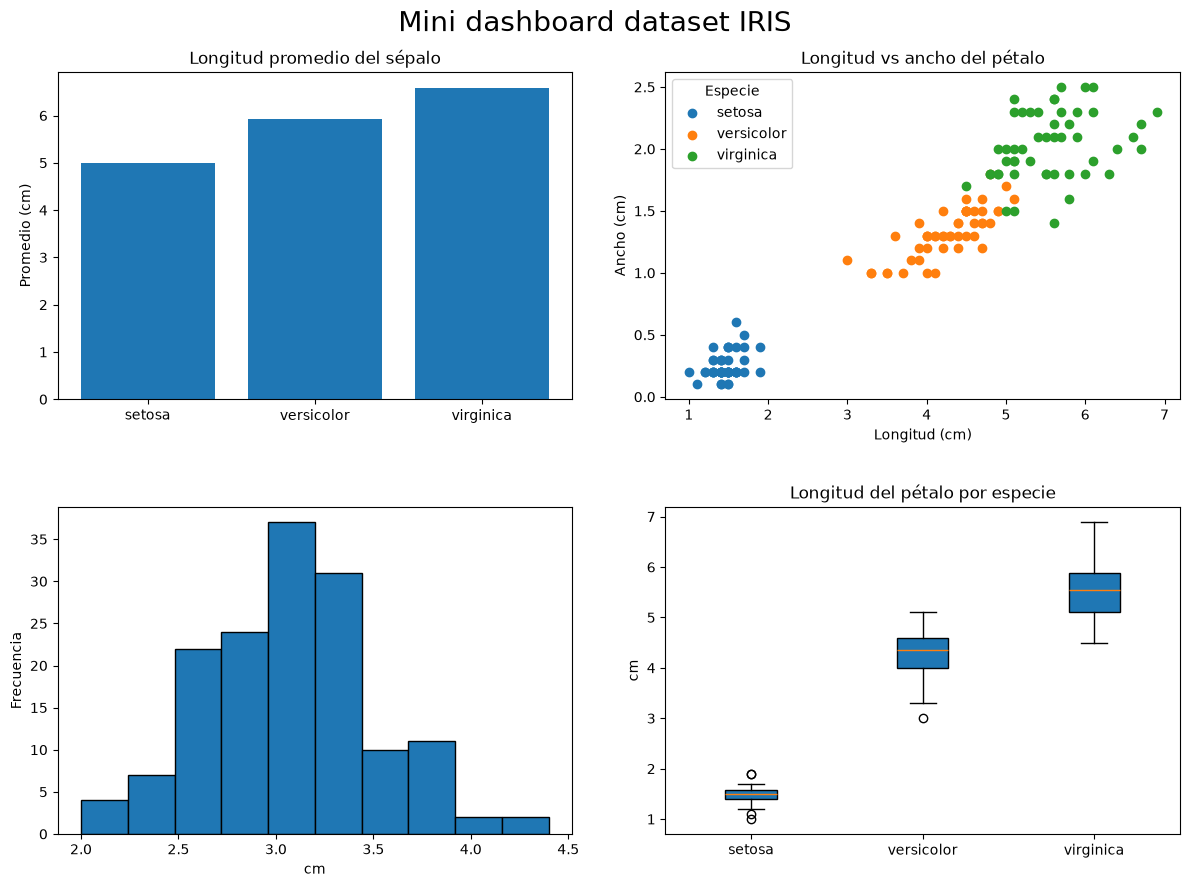

In [67]:
# 20. Mini dashboard final
# Construye una figura 2x2 que resuma el dataset con cuatro visualizaciones diferentes: (1) barras del promedio de longitud de sépalo por especie, (2) scatter de longitud 
# vs. ancho de pétalo por especie, (3) histograma de ancho de sépalo y (4) boxplot de longitud de pétalo por especie. Usa POO, títulos claros, leyendas cuando correspondan 
# y `tight_layout()`.

fig, axes =plt.subplots(2, 2, figsize=(12, 9))

mean_sepal = df.groupby('species')['sepal_length_cm'].mean()
axes[0,0].bar(mean_sepal.index, mean_sepal.values)
axes[0,0].set_title('Longitud promedio del sépalo')
axes[0,0].set_ylabel('Promedio (cm)')

for specie, group in df.groupby('species'):
    axes[0,1].scatter(
        group['petal_length_cm'],
        group['petal_width_cm'],
        label=specie
    )

axes[0,1].set_title('Longitud vs ancho del pétalo')
axes[0,1].set_xlabel('Longitud (cm)')
axes[0,1].set_ylabel('Ancho (cm)')
axes[0,1].legend(title='Especie')


axes[1,0].hist(df['sepal_width_cm'], bins=10, edgecolor='black')
axes[1,0].set_xlabel('cm')
axes[1,0].set_ylabel('Frecuencia')

species_unicas = list(df['species'].unique())
species_unicas = list(df["species"].unique())
print(species_unicas)

longitudes_petalo = [
    df[df["species"] == especie]["petal_length_cm"]
    for especie in species_unicas
]

axes[1, 1].boxplot(longitudes_petalo, tick_labels=species_unicas, patch_artist=True)
axes[1, 1].set_title("Longitud del pétalo por especie")
axes[1, 1].set_ylabel("cm")

fig.suptitle("Mini dashboard dataset IRIS", fontsize=20)
fig.tight_layout(h_pad=3, w_pad=3)
plt.show()

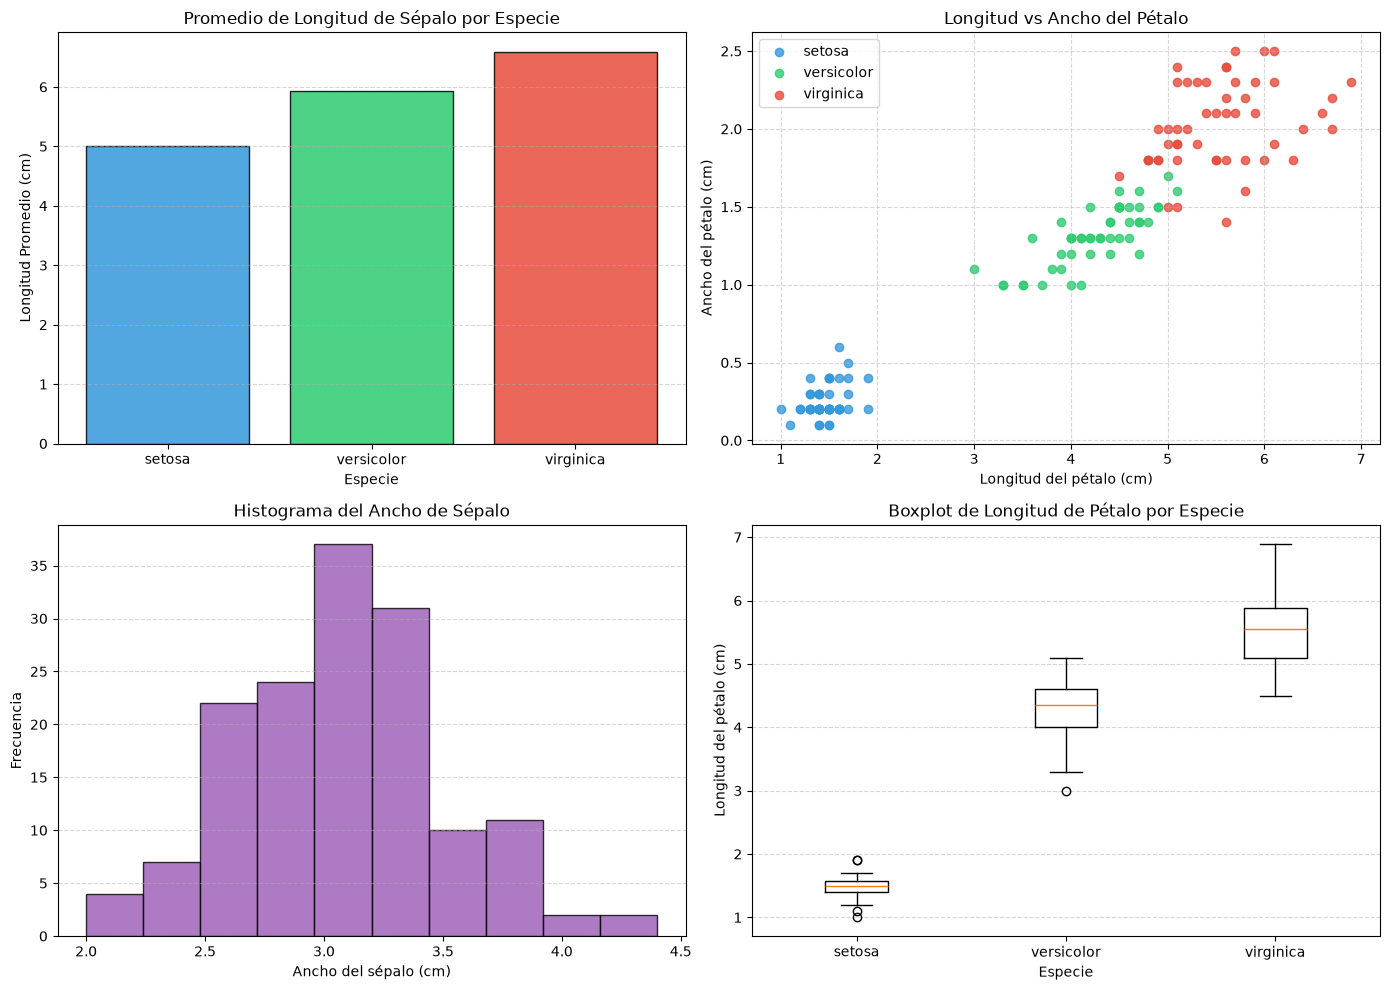

In [ ]:
# 20. Mini dashboard final
# Construye una figura 2x2 que resuma el dataset con cuatro visualizaciones diferentes: (1) barras del promedio de longitud de sépalo por especie, (2) scatter de longitud 
# vs. ancho de pétalo por especie, (3) histograma de ancho de sépalo y (4) boxplot de longitud de pétalo por especie. Usa POO, títulos claros, leyendas cuando correspondan 
# y `tight_layout()`.

# import matplotlib.pyplot as plt

# 1. Crear la figura y la cuadrícula de 2x2 subplots usando POO
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Definir especies y colores consistentes para los gráficos
especies = df["species"].unique()
colores = {"setosa": "#3498db", "versicolor": "#2ecc71", "virginica": "#e74c3c"}

# --- (1) Gráfico de barras: Promedio de longitud de sépalo por especie ---
promedio_sepal = df.groupby("species")["sepal_length_cm"].mean().reset_index()
axs[0, 0].bar(
    promedio_sepal["species"],
    promedio_sepal["sepal_length_cm"],
    color=[colores[esp] for esp in promedio_sepal["species"]],
    edgecolor="black",
    alpha=0.85,
)
axs[0, 0].set_title("Promedio de Longitud de Sépalo por Especie")
axs[0, 0].set_xlabel("Especie")
axs[0, 0].set_ylabel("Longitud Promedio (cm)")
axs[0, 0].grid(axis="y", linestyle="--", alpha=0.5)

# --- (2) Scatter plot: Longitud vs. Ancho de pétalo por especie ---
for esp in especies:
  subset = df[df["species"] == esp]
  axs[0, 1].scatter(
      subset["petal_length_cm"],
      subset["petal_width_cm"],
      label=esp,
      color=colores[esp],
      alpha=0.8,
  )
axs[0, 1].set_title("Longitud vs Ancho del Pétalo")
axs[0, 1].set_xlabel("Longitud del pétalo (cm)")
axs[0, 1].set_ylabel("Ancho del pétalo (cm)")
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle="--", alpha=0.5)

# --- (3) Histograma: Ancho de sépalo ---
axs[1, 0].hist(
    df["sepal_width_cm"], bins=10, edgecolor="black", color="#9b59b6", alpha=0.8
)
axs[1, 0].set_title("Histograma del Ancho de Sépalo")
axs[1, 0].set_xlabel("Ancho del sépalo (cm)")
axs[1, 0].set_ylabel("Frecuencia")
axs[1, 0].grid(axis="y", linestyle="--", alpha=0.5)

# --- (4) Boxplot: Longitud de pétalo por especie ---
datos_box = [df[df["species"] == esp]["petal_length_cm"] for esp in especies]
axs[1, 1].boxplot(datos_box)
axs[1, 1].set_xticklabels(especies)
axs[1, 1].set_title("Boxplot de Longitud de Pétalo por Especie")
axs[1, 1].set_xlabel("Especie")
axs[1, 1].set_ylabel("Longitud del pétalo (cm)")
axs[1, 1].grid(axis="y", linestyle="--", alpha=0.5)

# Ajuste automático del diseño para evitar superposiciones
plt.tight_layout()
plt.show()
